In [82]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import datetime
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import get_data_auto, fetch_alpaca_vbt_data
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
import optuna




# Data Handling

Working perfectly! (might need to reformat for multi index data)

In [2]:
# Fetch price data
symbol = "AAPL"
start = "2023-01-01"
end = "2024-01-01"
df = get_data_auto(symbol, start, end, timeframe_unit="Day")

In [3]:
df = vbt.YFData.download("AAPL", start="2023-01-01", end="2024-01-01")

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()


FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e0b72ea3-2333-4047-8700-00d1ca31351b',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 5, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([123.4706192 , 124.744133  , 123.42124939, ..., 191.74581909,
                          192.17269897, 191.13034058])}],
    'layout': {'height': 350,
               'legend': {'orientation': 

In [4]:
df = fetch_alpaca_vbt_data("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'b56ac264-0806-4b9f-8c62-35a5930a7305',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,
                          'xanchor': 'righ

In [5]:
df = get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '72cefcc8-a543-4481-be07-d82014d92deb',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,
                          'xanchor': 'righ

In [6]:
df = get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Day", multiplier=1)

# Access OHLCV as NumPy
close = df.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f3d15eb5-2c64-44c3-b918-655d7f0936db',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 5, 5, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2023, 12, 27, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 28, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 12, 29, 5, 0, tzinfo=datetime.timezone.utc)],
                         dtype=object),
              'y': array([123.4706192 , 124.744133  , 123.42124939, ..., 191.74581909,
                          192.17269897, 191.13034058])}],
    'layout': {'height': 350,
               'legend': {'orientation': 

In [7]:
df= get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Day", multiplier=1)

# Plot 
df.vbt.ohlcv.plot()


FigureWidget({
    'data': [{'close': array([123.4706192 , 124.744133  , 123.42124939, ..., 191.74581909,
                              192.17269897, 191.13034058]),
              'decreasing': {'line': {'color': '#d95f02'}},
              'high': array([129.22606012, 127.01472405, 126.13608258, ..., 192.0932807 ,
                             193.24484932, 192.98674117]),
              'increasing': {'line': {'color': '#1b9e76'}},
              'low': array([122.58212679, 123.4805026 , 123.16457967, ..., 189.70079744,
                            191.76567599, 190.3361534 ]),
              'name': 'OHLC',
              'open': array([128.61399343, 125.26735425, 125.50426746, ..., 191.09062872,
                             192.72862542, 192.49037608]),
              'type': 'ohlc',
              'uid': '1e6fecf2-7251-4347-b44c-7e0995aaee9e',
              'x': array([datetime.datetime(2023, 1, 3, 5, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2023, 1, 4,

In [8]:
df= get_data_auto("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Plot 
df.vbt.ohlcv.plot()

FigureWidget({
    'data': [{'close': array([131.3   , 131.    , 130.38  , ..., 192.26  , 192.1894, 192.1501]),
              'decreasing': {'line': {'color': '#d95f02'}},
              'high': array([131.46  , 131.4   , 131.25  , ..., 192.53  , 192.2599, 192.24  ]),
              'increasing': {'line': {'color': '#1b9e76'}},
              'low': array([130.28, 130.8 , 130.05, ..., 192.  , 192.13, 192.1 ]),
              'name': 'OHLC',
              'open': array([130.28  , 131.4   , 130.91  , ..., 192.3702, 192.2599, 192.14  ]),
              'type': 'ohlc',
              'uid': '81ff97d3-5cab-4492-afc3-99d37da6e986',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          date

In [9]:
df_day = get_data_auto("AAPL", "2023-01-01", "2023-06-01", timeframe_unit="Day")
df_hour = get_data_auto("AAPL", "2023-01-01", "2023-06-01", timeframe_unit="Hour", multiplier=1)

# Shape
print("SHAPES:")
print("Day:", df_day.shape)
print("Hour:", df_hour.shape)

# Columns
print("\nCOLUMNS:")
print("Day:", df_day.columns)
print("Hour:", df_hour.columns)

# Dtypes
print("\nDTYPES:")
print("Day:\n", df_day.dtypes)
print("Hour:\n", df_hour.dtypes)

# Index type and name
print("\nINDEX TYPE AND NAME:")
print("Day:", type(df_day.index), df_day.index.name)
print("Hour:", type(df_hour.index), df_hour.index.name)

# Columns name
print("\nCOLUMNS NAME:")
print("Day:", df_day.columns.name)
print("Hour:", df_hour.columns.name)

# Head preview
print("\nHEAD (Day):\n", df_day.head())
print("\nHEAD (Hour):\n", df_hour.head())

#They are Identical, just different timeframes
print("After checking print statements, they are identical")

SHAPES:
Day: (103, 5)
Hour: (1608, 5)

COLUMNS:
Day: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='field')
Hour: Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='field')

DTYPES:
Day:
 field
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object
Hour:
 field
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

INDEX TYPE AND NAME:
Day: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> timestamp
Hour: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> timestamp

COLUMNS NAME:
Day: field
Hour: field

HEAD (Day):
 field                            Open        High         Low       Close  \
timestamp                                                                   
2023-01-03 05:00:00+00:00  128.613978  129.226044  122.582112  123.470604   
2023-01-04 05:00:00+00:00  125.267339  127.014709  123.480487  124.744118   
2023-01-05 05:00:0

# Indicators/Strategies, Portfolios and Order types

## Basic Indicators


In [91]:
# There are many many more indicators available in TA-Lib

# Access OHLCV as NumPy
close = df["Close"].values.astype(np.float64)

# Various Basic indicators:
sma_20 = talib.SMA(close, timeperiod=20).astype(np.float32)
sma_ind = vbt.IndicatorFactory.from_talib("SMA")


ema_20 = talib.EMA(close, timeperiod=20).astype(np.float32)
ema_ind = vbt.IndicatorFactory.from_talib("EMA")

rsi_14 = talib.RSI(close, timeperiod=14).astype(np.float32)
rsi_ind = vbt.IndicatorFactory.from_talib("RSI")


macd, macd_signal, macd_hist = [x.astype(np.float32) for x in talib.MACD(close)]

bb_middle, bb_upper, bb_lower = [x.astype(np.float32) for x in talib.BBANDS(
    close, timeperiod=20, nbdevup=2.0, nbdevdn=2.0, matype=0)]


### Basic RSI Indicator/Strategy and Optimization

In [11]:
# Calculating RSI Indicator; 
rsi_values = talib.RSI(df['Close'].values, timeperiod=14) 

# PLotting RSI Indicator
rsi_series = pd.Series(rsi_values, index=df.index, name="RSI")
rsi_series.vbt.plot(title=f"{symbol} RSI (14)", yaxis_title="RSI")

FigureWidget({
    'data': [{'name': 'RSI',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'efac6a25-52dc-4f41-9f7a-d5a44ff8bb6f',
              'x': array([datetime.datetime(2023, 1, 3, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 10, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 11, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 22, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 23, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'y': array([        nan,         nan,         nan, ..., 35.22838005, 34.34556285,
                          33.83723315])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,


In [12]:
# Single Case RSI
rsi_values = talib.RSI(df['Close'].values, timeperiod=14) 

# Define the signals based on continuous logic:
signals= np.where(rsi_values < 30, 1, 0) 
signals= np.where(rsi_values > 70, -1, signals)

entries = signals == 1
exits = signals == -1

pf = vbt.Portfolio.from_signals(
    close = df['Close'],
    entries=entries,
    exits=exits,
    init_cash=10000,
    fees=0.001,
    slippage=0.001
)
print(pf.total_return())
pf.plot().show()


0.1094340653569383


In [13]:
# RSI Strategy (not efficently computed, ony ticker max, no timeframes):

#Define the RSI strategy logic:
def rsi_strategy(close, rsi_period=14, entry_threshold=30, exit_threshold=70): 
    # Calculate RSI, if we use vbt fuunction we can use @njit compilation
    rsi = talib.RSI(close.flatten(), timeperiod = rsi_period) 

    # Define the signals based on continuous logic:
    signals= np.where(rsi < entry_threshold, 1, 0) 
    signals= np.where(rsi > exit_threshold, -1, signals)
    return signals


# Define RSI strategy function for vbt compatability
rsi_ind = IndicatorFactory(
    class_name="RSIStrategy",
    short_name="RSI",
    input_names=["close"],
    param_names=["rsi_period", "entry_threshold", "exit_threshold"],
    output_names=["signals"],
    ).from_apply_func(
        rsi_strategy,
        rsi_period=14,
        entry_threshold=30,
        exit_threshold=70,
        )

# Runnning the strategy with single parameterization
res = rsi_ind.run(
    close=df['Close'],
    rsi_period=14,
    entry_threshold=30,
    exit_threshold=70,
)

# Outputting the results
pf = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res.signals == 1.0,
    exits=res.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


pf.total_return()


0.10943406535693924

## Custom Indicator/Strategy!!!
(with RAM reduction techniques and numby complied for max computational efficiency)

In [ ]:
ema = vbt.IndicatorFactory.from_talib("EMA")

@njit # Just-in-time compilation for performance
def custom_signal_logic(short_ema, med_ema, long_ema):
    # Define the signals based on continuous logic:
    signals = np.where((short_ema > med_ema) & (med_ema > long_ema), 1, 0) 
    signals = np.where(short_ema < med_ema, -1, signals)
    return signals

def custom_indicator(close, short_ema=12, med_ema=26, long_ema=50):
    s_ema = ema_ind.run(close, timeperiod=short_ema).real.to_numpy()
    m_ema = ema_ind.run(close, timeperiod=med_ema).real.to_numpy()
    l_ema = ema_ind.run(close, timeperiod=long_ema).real.to_numpy()
    return custom_signal_logic(s_ema, m_ema, l_ema)

# Define RSI strategy function for vbt compatability
custom = IndicatorFactory(
    class_name="CustomStrategy",
    short_name="Custom",
    input_names=["close"],
    param_names=["short_ema", "med_ema", "long_ema"],
    output_names=["signals"],
    ).from_apply_func(
        custom_indicator,
        short_ema=12,
        med_ema=26,
        long_ema=50,
        )

# Runnning the strategy with single parameterization
res2 = custom.run(
    close=df['Close'],
    short_ema=12,
    med_ema=26,
    long_ema=50,
    )

# Outputting the results
pf2 = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res2.signals == 1.0,
    exits=res2.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


pf2.total_return()



0.12062398528292291

## Using Order types

In [120]:
@njit # Just-in-time compilation for performance
def custom_signal_logic2(close, ema, rsi, entries, exits):
    # Define the signals based on continuous logic:
    signals = np.where((rsi < entries) & (close > ema), 1, 0)
    signals = np.where(rsi > exits, -1, signals)
    return signals

def custom_indicator2(close, ema=12, period=14, entries=30, exits=70, sl_trail=0.05, tp_stop=0.1, sl_stop=0.05):
    ema = ema_ind.run(close, timeperiod=ema).real.to_numpy()
    rsi = rsi_ind.run(close, timeperiod=period ).real.to_numpy()
    return custom_signal_logic2(close, ema, rsi, entries, exits), np.broadcast_to(sl_trail, close.shape), np.broadcast_to(tp_stop, close.shape), np.broadcast_to(sl_stop, close.shape)

# Define RSI strategy function for vbt compatability
custom2 = IndicatorFactory(
    class_name="CustomStrategy2",
    short_name="Custom2",
    input_names=["close"],
    param_names=["ema", "period", "entries", "exits", "sl_trail", "tp_stop", "sl_stop"],
    output_names=["signals", "sl_trail", "tp_stop", "sl_stop"],
    ).from_apply_func(
        custom_indicator2,
        ema=12,
        period=14,
        entries=30,
        exits=70,
        sl_trail=0.05,
        tp_stop=0.1,
        sl_stop=0.05,
        )

# Runnning the strategy with single parameterization
res3 = custom2.run(
    close=df['Close'],
    ema=12,
    period=14,
    entries=30,
    exits=70,
    sl_trail=0.05,
    tp_stop=0.1,
    sl_stop=0.05,
    )

# Outputting the results
pf3_orders = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res3.signals == 1.0,
    exits=res3.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    sl_stop=res3.sl_stop, # 5% stop loss
    tp_stop=res3.tp_stop, # 10% take profit
    sl_trail=res3.sl_trail # 5% trailing stop loss
    )

pf3_orders.total_return()


0.02399636450265888

# Optimisation and Overfitting

## Optimising 

#### Optimising Basic RSI

In [14]:
# Runnning the strategy with multi parameterization
rsi_period = list(range(14, 29, 1))           
entry_threshold = list(range(5, 36, 1))      
exit_threshold = list(range(50, 81, 1)) 

res = rsi_ind.run(
    close=df['Close'],
    rsi_period=rsi_period,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    param_product=True
)

pf = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res.signals == 1.0,
    exits=res.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    )


print(pf.total_return())
print(pf.total_return().shape[0])
print(max(pf.total_return()))

RSI_rsi_period  RSI_entry_threshold  RSI_exit_threshold
14              5                    50                    0.000000
                                     51                    0.000000
                                     52                    0.000000
                                     53                    0.000000
                                     54                    0.000000
                                                             ...   
28              35                   76                    0.456845
                                     77                    0.463607
                                     78                    0.469157
                                     79                    0.519905
                                     80                    0.519905
Name: total_return, Length: 14415, dtype: float64
14415
0.5672884919684634


In [15]:
returns = pf.total_return()
# If i wanna collapse an axis to a single value by taking the mean
#returns = returns.groupby(level=["RSI_entry_threshold", "RSI_exit_threshold"]).mean()

# # Plotting 2D heatmap with slider
fig = returns.vbt.heatmap(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    slider_level="RSI_rsi_period",
    title="RSI Strategy Returns",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Total Return")
    ).show()

In [16]:
fig = returns.vbt.volume(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    z_level="RSI_rsi_period",
    title="RSI Strategy Returns",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Total Return")
    ).show()

looking at the volume and heat map, plus the optimal value, we can see a stable region of consistencely high values with larger entry values and larger exit values, we can also see the period does seem to imporve performance as we increase from 14 to 28, however  not by much. From visual inspection we can see this description isnt an annomely but described the whole behaviour so we have some level of confidence picking parameters in these regions are not overfitted

by examinations we can see the most optimal parameters are entr= 35, exit= 80, rsi_window= 22, however this does seem to be a slight overfit when we take our analysis into consideration as there is a larger group of consisten above 50% return at higher rsi window values such as 27,28. Instead of just the one largest value surronded by smaller ones locally

#### Optimising Custom Strategy

Other ideas for Optimisation in general:

🔹 A. Adaptive Refinement
Run a coarse grid first.

Identify good regions.

Re-run with higher resolution around those.

🔹 B. Smart Sampling (Bayesian Optimization)
Use tools like optuna, skopt, or scikit-optimize to:

Model the return surface

Focus sampling on high-potential zones

Skip obviously bad areas

This often finds better parameters with 90% fewer evaluations.

In [148]:
ema_vals = np.arange(2, 30, 10)
rsi_periods = np.arange(7, 35, 7)
entry_levels = np.arange(10, 40, 5)
exit_levels = np.arange(60, 90, 5)

sl_trail_range = np.arange(0.01, 0.11, 0.02)
tp_stop_range = np.arange(0.01, 0.2, 0.05)
print(ema_vals)

[ 2 12 22]


In [ ]:
# Optiona A:  

# Imbedding in a for loop will reduce RAM usage, 
# but increase time to run by non_loop_run*num_combinations looped 
# If and only if: non_loop_run isnt capped by RAM and cache or processing power

res3 = custom2.run(
    close=df['Close'],
    ema=ema_vals,
    period=rsi_periods,
    entries=entry_levels,
    exits=exit_levels,
    sl_trail=sl_trail_range,
    tp_stop=tp_stop_range,
    sl_stop=0.05, # we Adont use this but we could 
    param_product=True
)

# This is Fastest way to get optimization values, however its not most RAM efficient
pf3 = vbt.Portfolio.from_signals(
    close=df['Close'],
    entries=res3.signals == 1.0,
    exits=res3.signals == -1.0,
    size=1,
    fees=0.001,
    slippage=0.001,
    sl_trail= res3.sl_trail, # 5% stop loss
    tp_stop= res3.tp_stop, # 10% take profit
    freq = "h"
)

# Use pf3 instead of pf, and handle the output shape (likely a MultiIndex Series)
total_ret = pf3.total_return()
best_index = total_ret.idxmax()
best_return = total_ret.max()
print("Best Params:", best_index)
print("Best Return:", best_return)


Best Params: (2, 21, 35, 85, 0.01, 0.16000000000000003, 0.05)
Best Return: 0.4985941331416279


In [146]:
pf3.stats() # Show stats of the all portfolio combinations

C:\Users\narut\AppData\Local\Temp\ipykernel_30024\3018795306.py:1: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x0000022412104F40>. Pass column to select a single column/group.



Start                          2023-01-03 09:00:00+00:00
End                            2023-12-30 00:00:00+00:00
Period                                 164 days 18:00:00
Start Value                                        100.0
End Value                                     100.653203
Total Return [%]                                0.653203
Benchmark Return [%]                           46.344326
Max Gross Exposure [%]                         31.944444
Total Fees Paid                                 0.343282
Max Drawdown [%]                                7.533875
Max Drawdown Duration         63 days 01:51:18.260869565
Total Trades                                    1.673032
Total Closed Trades                             1.619213
Total Open Trades                               0.053819
Open Trade PnL                                  0.019626
Win Rate [%]                                   64.893189
Best Trade [%]                                  2.889931
Worst Trade [%]                

In [ ]:
# Optiona A with for loop:  
best_result = {
    'ema': None,
    'best_index': None,
    'best_return': -np.inf,
    'pf': None  # store best-performing portfolio object
}

for ema_value in ema_vals:
    # Imbedding in a for loop will reduce RAM usage, but increase time *num_combinations looped
    res3 = custom2.run(
        close=df['Close'],
        ema=ema_value,
        period=rsi_periods,
        entries=entry_levels,
        exits=exit_levels,
        sl_trail=sl_trail_range,
        tp_stop=tp_stop_range,
        sl_stop=0.05, # we Adont use this but we could 
        param_product=True
    )

    # This is Fastest way to get optimization values, however its not most RAM efficient
    pf3 = vbt.Portfolio.from_signals(
        close=df['Close'],
        entries=res3.signals == 1.0,
        exits=res3.signals == -1.0,
        size=1,
        fees=0.001,
        slippage=0.001,
        sl_trail= res3.sl_trail, # 5% stop loss
        tp_stop= res3.tp_stop, # 10% take profit
        freq = "h"
    )

    total_ret = pf3.total_return()
    idx = total_ret.idxmax()
    val = total_ret.max()

    if val > best_result['best_return']:
        best_result.update({
            'ema': ema_value,
            'best_index': idx,
            'best_return': val,
            'pf': pf3
        })


# Use pf3 instead of pf, and handle the output shape (likely a MultiIndex Series)
print("✅ Best EMA Value:", best_result['ema'])
print("📊 Best Param Index:", best_result['best_index'])
print("💰 Best Return:", best_result['best_return'])

and trying to follow the gradient descent method


✅ Best EMA Value: 2
📊 Best Param Index: (2, 21, 35, 85, 0.01, 0.16000000000000003, 0.05)
💰 Best Return: 0.4985941331416279


In [ ]:
# Option B: 

# Here we use only testing random values, and trying to test smarter values with a cap and then gives the best
def objective(trial):
    ema = trial.suggest_categorical("ema", ema_vals.tolist())
    period = trial.suggest_categorical("period", rsi_periods.tolist())
    entry = trial.suggest_categorical("entries", entry_levels.tolist())
    exit = trial.suggest_categorical("exits", exit_levels.tolist())
    sl_trail = trial.suggest_categorical("sl_trail", sl_trail_range.tolist())
    tp_stop = trial.suggest_categorical("tp_stop", tp_stop_range.tolist())

    try:
        # Compute signals
        res = custom2.run(
            close=df['Close'].astype(np.float64),
            ema=ema,
            period=period,
            entries=entry,
            exits=exit,
            sl_trail=sl_trail,
            tp_stop=tp_stop
        )

        # Run backtest
        pf = vbt.Portfolio.from_signals(
            close=df['Close'].astype(np.float64),
            entries=res.signals == 1.0,
            exits=res.signals == -1.0,
            size=1,
            fees=0.001,
            slippage=0.001,
            sl_trail=sl_trail,
            tp_stop=tp_stop
        )

        return pf.total_return().item()

    except Exception as e:
        print("Trial failed:", e)
        return -np.inf
    
    

# Run optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# Print results
print("Best return:", study.best_value)
print("Best parameters:", study.best_params)

[I 2025-05-24 05:22:33,930] A new study created in memory with name: no-name-a39acff9-02fd-4d9e-a84a-25ee3e0af86f
[I 2025-05-24 05:22:33,982] Trial 0 finished with value: -0.0872635968652122 and parameters: {'ema': 2, 'period': 14, 'entries': 30, 'exits': 65, 'sl_trail': 0.01, 'tp_stop': 0.11}. Best is trial 0 with value: -0.0872635968652122.
[I 2025-05-24 05:22:34,035] Trial 1 finished with value: 0.00846794542742316 and parameters: {'ema': 12, 'period': 14, 'entries': 35, 'exits': 60, 'sl_trail': 0.049999999999999996, 'tp_stop': 0.060000000000000005}. Best is trial 1 with value: 0.00846794542742316.
[I 2025-05-24 05:22:34,088] Trial 2 finished with value: 0.0 and parameters: {'ema': 2, 'period': 28, 'entries': 10, 'exits': 65, 'sl_trail': 0.01, 'tp_stop': 0.16000000000000003}. Best is trial 1 with value: 0.00846794542742316.
[I 2025-05-24 05:22:34,141] Trial 3 finished with value: 0.0 and parameters: {'ema': 12, 'period': 7, 'entries': 30, 'exits': 75, 'sl_trail': 0.04999999999999999

Best return: 0.48846801087699276
Best parameters: {'ema': 2, 'period': 14, 'entries': 35, 'exits': 85, 'sl_trail': 0.08999999999999998, 'tp_stop': 0.16000000000000003}


#### Optimizing for arbitrary conditions!!!

In [ ]:
# These are a bunch of metrics we could examine or Optimise for, we dont need to 
# optimise for returns, plus we could do something like returns/max_drawdown or any other combination
# we can also do something like, if trade_count below 10, return -1, etc
# or trim certain values such as if sharpe==inf, return 0, etc etc.

print(pf3.total_return())
print(pf3.returns())
print(pf3.sharpe_ratio(freq="h"))
print(pf3.max_drawdown())
print(pf3.stats())
print(pf3.trades)
print(pf3.orders)
print(pf3.positions)
print(pf3.value())

print("Trade count:", pf3.trades.count())
print("Fraction of winning trades:", pf3.trades.win_rate())
print("Trade PnL series:\n", pf3.trades.pnl)
print("Trade stats summary:\n", pf3.trades.stats())
print("Readable trade records:\n", pf3.trades.records_readable)


Custom2_ema  Custom2_period  Custom2_entries  Custom2_exits  Custom2_sl_trail  Custom2_tp_stop  Custom2_sl_stop
22           7               10               60             0.01              0.01             0.05               0.0
                                                                               0.06             0.05               0.0
                                                                               0.11             0.05               0.0
                                                                               0.16             0.05               0.0
                                                             0.03              0.01             0.05               0.0
                                                                                                                  ... 
             28              35               85             0.07              0.16             0.05               0.0
                                                       

C:\Users\narut\AppData\Local\Temp\ipykernel_30024\4020101733.py:5: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x0000022412104F40>. Pass column to select a single column/group.

C:\Users\narut\AppData\Local\Temp\ipykernel_30024\4020101733.py:14: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x0000022412104F40>. Pass column to select a single column/group.



In [195]:
def objective_function(pf: vbt.Portfolio) -> pd.Series:
    stats = pf.trades.stats()

    expectancy = stats.loc["Expectancy"]
    max_dd = -pf.max_drawdown()
    max_dd = max_dd.replace(0, np.nan)

    score = expectancy / max_dd
    return score




scores = objective_function(pf3)

best_index = scores.idxmax()
best_portfolio = pf3[best_index]

best_portfolio.plot().show()

C:\Users\narut\AppData\Local\Temp\ipykernel_30024\605245709.py:2: UserWarning:

Object has multiple columns. Aggregating using <function mean at 0x0000022412104F40>. Pass column to select a single column/group.



## Reducing Overfitting!!!


### Basic RSI

In [ ]:
results = pf.total_return().values
print(results.shape)
return_grid = results.reshape(len(rsi_period), len(entry_threshold), len(exit_threshold))
print("Return grid shape:", return_grid.shape)

# Define the smoothing size
smoothing_size = 3


(14415,)
Return grid shape: (15, 31, 31)


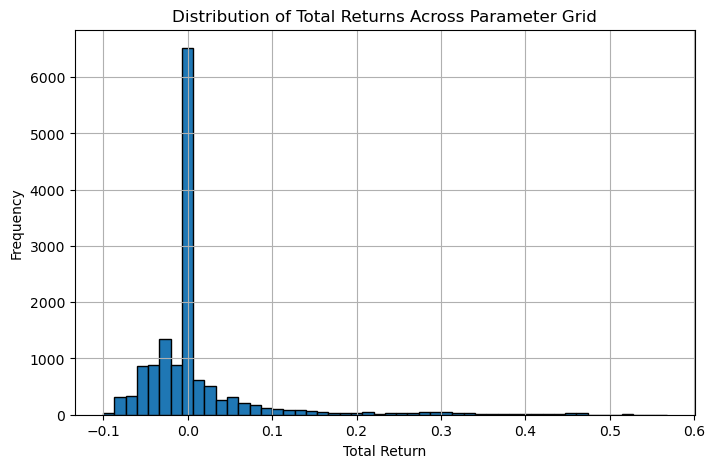

In [20]:
flat_returns = return_grid.flatten()
# Studying the distribution of total returns

plt.figure(figsize=(8, 5))
plt.hist(flat_returns, bins=50, edgecolor='black')
plt.title("Distribution of Total Returns Across Parameter Grid")
plt.xlabel("Total Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


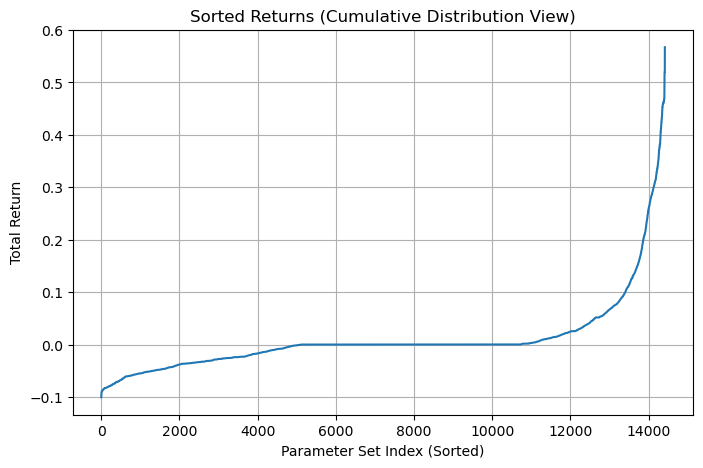

In [21]:
# Studying the distribution of returns
sorted_returns = np.sort(flat_returns)

plt.figure(figsize=(8, 5))
plt.plot(sorted_returns)
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


In [ ]:
def crop_with_padding(grid: np.ndarray, pad: int = 3) -> tuple:
    """
    Crops a NumPy array by removing zero-only margins and leaves padding in all dimensions.

    Parameters:
        grid (np.ndarray): Input N-dimensional array.
        pad (int): Number of elements to retain as padding after the non-zero boundary.

    Returns:
        cropped_grid (np.ndarray): Cropped version of the input.
        slices (list of slice): List of slice objects used for cropping (for index tracking).
    """
    nonzero_mask = grid != 0
    coords = np.argwhere(nonzero_mask)

    if coords.size == 0:
        raise ValueError("Grid contains only zeros")

    min_bounds = coords.min(axis=0)
    max_bounds = coords.max(axis=0) + 1  # Inclusive

    # Apply padding and clip to bounds
    slices = []
    for dim in range(grid.ndim):
        start = max(min_bounds[dim] - pad, 0)
        end = min(max_bounds[dim] + pad, grid.shape[dim])
        slices.append(slice(start, end))

    # Slice the grid
    cropped_grid = grid[tuple(slices)]
    return cropped_grid, slices


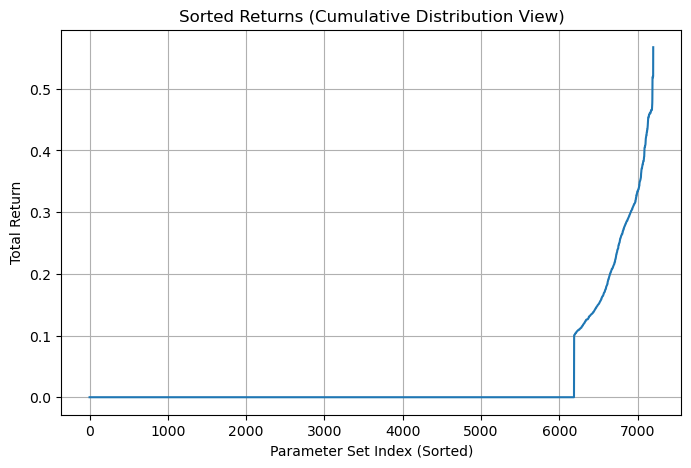

In [ ]:
threshold = 0.1
filtered_grid = np.where(return_grid >= threshold, return_grid, 0)
cropped_grid, slices = crop_with_padding(filtered_grid, pad=smoothing_size)

cropped_grid, slices = crop_with_padding(filtered_grid, pad=3)

cropped_rsi = rsi_period[slices[0]]
cropped_entry = entry_threshold[slices[1]]
cropped_exit = exit_threshold[slices[2]]


flat_filtered_cropped_returns = cropped_grid.flatten()
sorted_filtered_cropped_returns = np.sort(flat_filtered_cropped_returns)

plt.figure(figsize=(8, 5))
plt.plot(sorted_filtered_cropped_returns)
plt.title("Sorted Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Total Return")
plt.grid(True)
plt.show()


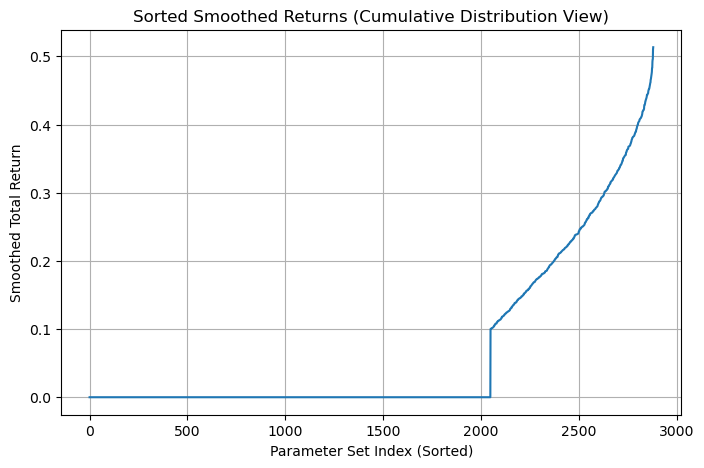

In [ ]:
smoothed_grid = uniform_filter(cropped_grid, size=smoothing_size) # 3x smoothing in every dimension
# Could potentially imporve this using GPU and a different method


final_filtered_grid = np.where(smoothed_grid >= 0.1, smoothed_grid, 0.0)
final_cropped_grid, slices = crop_with_padding(final_filtered_grid, pad=1)
final_rsi = cropped_rsi[slices[0]]
final_entry = cropped_entry[slices[1]]
final_exit = cropped_exit[slices[2]]


flat_smoothed_returns = final_cropped_grid.flatten()
sorted_smoothed_returns = np.sort(flat_smoothed_returns)


plt.figure(figsize=(8, 5))
plt.plot(sorted_smoothed_returns)
plt.title("Sorted Smoothed Returns (Cumulative Distribution View)")
plt.xlabel("Parameter Set Index (Sorted)")
plt.ylabel("Smoothed Total Return")
plt.grid(True)
plt.show()

In [60]:
best_index = np.unravel_index(np.argmax(smoothed_grid), smoothed_grid.shape)
best_rsi = cropped_rsi[best_index[0]]
best_entry = cropped_entry[best_index[1]]
best_exit = cropped_exit[best_index[2]]

print(f"🔥 Best stable combo: RSI={best_rsi}, Entry={best_entry}, Exit={best_exit}")
print(f"Estimated Return at that combo: {smoothed_grid[best_index]:.4f}")

🔥 Best stable combo: RSI=28, Entry=35, Exit=80
Estimated Return at that combo: 0.5134


In [ ]:
# Get all parameter combinations as tuples
index = pd.MultiIndex.from_product(
    [final_rsi, final_entry, final_exit],
    names=["RSI_rsi_period", "RSI_entry_threshold", "RSI_exit_threshold"]
)

# Flatten the smoothed grid
flat_final_values = final_cropped_grid.flatten()

# Create a Series with MultiIndex
final_series = pd.Series(flat_final_values, index=index)

fig = final_series.vbt.volume(
    x_level="RSI_entry_threshold",
    y_level="RSI_exit_threshold",
    z_level="RSI_rsi_period",
    title="Final Smoothed + Filtered RSI Return Volume",
    xaxis_title="Entry Threshold",
    yaxis_title="Exit Threshold",
    coloraxis_colorbar=dict(title="Smoothed Return")
)
fig.show()


🔥 As predicted:

Best stable combo: RSI=28, Entry=35, Exit=80

Estimated Return at that combo: 0.5134

Critiques:

1) these "returns" approximate the real, they are averaged locally

(they at least tell us where, which is more important since we might have abstract colour values due to abstract optimisation function)

2) All metrics are treated equally, we arent looking at sharpe or max drawndown, etc

(easy to fix with abstract constraints)

3) No discretenization across time, or market regines, what works well during one period might change, and even if it was optimal, for those conditions ei a bullish market or other, it might get overshadowed by more long term strats of lower performance

(Good to consider, once we examine different market conditions and we are looking at specific time frames)

4) we havent tested on walk forward, and we chose a transaction threshold by looking at a graph, which will have to be something we always keep in mind

(Combining these problems we can tackle them together by optimising for the threshold)

In [58]:
# Finally we will compile all this into a function called:

# reduce_overfitting(smoothing_size=3, trancation_threshold=0.1)


# We can then Optimise, reduce overfitting
# then walk forward test and for these parameters 
# (most imporantly tranctation threshold) 


### Custom Strategy with arbbitrary conditions

# Other forms of Strategy Validation

Ideas: 
1) walk forward test
2) monte carlo 
3) Statistical tests
4) parameter sensitivity??
5) regime testing
6) edge or alpha decay 
7) robustness check

# Market Scanner

# I think the next sections can wait since they can get quite hard

# Time Sereies embedding and Evolving Dynamical Systems modelling, Signal PRocessing (probably best for sideways markets)